In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("mileston2processed_credit_risk.csv")

df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22.0,59000.0,123.0,35000.0,16.02,1.0,0.59,1,3.0,0,...,0,0,1,0,0,0,1,0,0,0
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,0,2.0,0,...,0,0,0,0,1,0,0,0,0,0
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,0,3.0,0,...,0,1,0,0,0,1,0,0,0,0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,0,2.0,0,...,0,1,0,0,0,1,0,0,0,0
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,1,4.0,0,...,0,1,0,0,0,1,0,0,0,0


In [4]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32416, 22)
Target shape: (32416,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (25932, 22)
Testing samples: (6484, 22)


In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Baseline Logistic Regression Model Trained ✅")

Baseline Logistic Regression Model Trained ✅


In [7]:
X.isnull().sum().sort_values(ascending=False)

,0
person_age,0
person_income,0
person_emp_length,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0
person_home_ownership_OTHER,0
person_home_ownership_OWN,0


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt

In [12]:
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_prob) * 100

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")
print(f"ROC-AUC   : {auc:.2f}%")

Accuracy  : 84.75%
Precision : 74.46%
Recall    : 46.05%
F1 Score  : 56.91%
ROC-AUC   : 84.77%


In [13]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[4842  224]
 [ 765  653]]


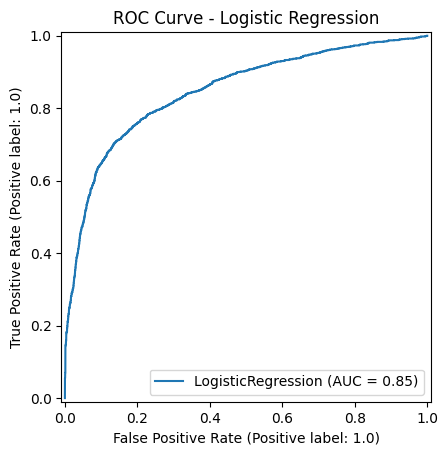

In [14]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [15]:
import joblib

joblib.dump(model, "baseline_model.pkl")
print("Baseline model saved ✅")

Baseline model saved ✅
